In [1]:
from SiNAPSE.core import Neuron, Recording, Database
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.io import wavfile

db_path = r"C:\Users\tmerri03\Desktop\Temp Neural Files\awake_recordings.db"
stim_lib = r'R:\Data\tyler\Recordings\Stim\Stimuli Library'
db = Database(db_path, stim_lib)

In [2]:
class Unit:
    def __init__(self, db, recording, neuron):
        self.db=db
        recordings_path = r'N:\Data\RhythmPerception\Neural Recordings'
        bird = recording.split('_')[0]
        recording_path = os.path.join(recordings_path, bird, recording)
        self.recording = recording
        self.neuron = neuron
        self.rec = Recording(recording_path, samplerate=30000, db=self.db)
        self.N = Neuron(recording, neuron, db=self.db, rec=self.rec)
        self.stims = self.N.load

    def baseline_stats(self, duration=2):
        baseline_trials, ntrials, nstimuli = self.N.collect_baseline(duration=duration)
        counts = np.array([len(t) for t in baseline_trials], dtype=float)  # spikes per trial

        # collect_baseline's trial length: duration * nstimuli (as in your baseline_fr)
        trial_dur = duration * nstimuli
        rates = counts / trial_dur                                         # Hz per trial

        mean_fr = rates.mean()
        if counts.mean() > 0 and len(counts) > 1:
            fano = counts.var(ddof=1) / counts.mean()
            cv_counts = counts.std(ddof=1) / counts.mean()
        else:
            fano = cv_counts = np.nan

        return dict(mean_fr=mean_fr, fano=fano, cv_counts=cv_counts)

    def spikewidth(self):
        return self.N.get_neuron_data['spike_width_pp']

    def cv_isi(self):
        trials, _, _ = self.N.collect_baseline(duration=2)
        isis = np.concatenate([np.diff(t) for t in trials if len(t) > 1])
        return isis.std() / isis.mean()

    def phase_locking(self, stimulus, beat_times, period_s, latency_s=0.020, window_s=None):
        """
        trial_spikes : list of arrays, spike times (s) per trial, same time frame as beat_times
        beat_times   : beat onset times (s)
        period_s     : beat period (s), used to convert time to phase
        latency_s    : shift the analysis window by the response latency
        window_s     : window length after each beat (default = one period)

        Returns dict: vector_strength, phase_rad, phase_ms, n_spikes, rayleigh_p
        """
        window_s = period_s if window_s is None else window_s
        phases = []
        _, trial_spikes, _ = self.N.raster(stimulus, baseline=False, plot=False, ax=None)
        for spikes in trial_spikes:
            spikes = np.asarray(spikes)
            for t in beat_times:
                near = spikes[(spikes >= t + latency_s) & (spikes < t + latency_s + window_s)]
                phases.append((near - t) / period_s * 2 * np.pi)
        phases = np.concatenate(phases) if phases else np.array([])

        n = len(phases)
        if n == 0:
            return dict(vector_strength=np.nan, phase_rad=np.nan, phase_ms=np.nan,
                        n_spikes=0, rayleigh_p=np.nan)

        z = np.mean(np.exp(1j * phases))
        vs = np.abs(z)
        phase = np.angle(z) % (2 * np.pi)          # 0 to 2π
        return dict(
            vector_strength=vs,
            phase_rad=phase,
            phase_ms=phase / (2 * np.pi) * period_s * 1000,
            n_spikes=n,
            rayleigh_p=np.exp(-n * vs**2),         # Rayleigh approximation, fine for n > ~50
        )

In [3]:
templates = {
    'o3o55 Recording #2 (77-H2, Field L, 1.4AP 1.2ML-R 1708um)': 217,
    'w46o62 Recording #2 (77-H2, Field L, 1.4AP 1.2ML-R 2231um)': 226,
}

def find_stim(U:Unit, tempo=180):
    STIM = None
    for stimulus in U.stims:
        if f'{tempo}ms_8b_1xomit_8b' in stimulus and not 'irregular' in stimulus:
            STIM = stimulus

    if STIM is None:
        return None, None

    element = r"C:\Users\tmerri03\Desktop\RhythmStimuli\Awake Recs\Raw Files\ZF A_20db.wav"
    sr, data = wavfile.read(element)
    duration_s = data.shape[0] / sr
    tempo = tempo/1000
    prestim = tempo+tempo-duration_s
    preomit = np.arange(0,8,1)*tempo+prestim
    postomit = np.arange(0,8,1)*tempo+prestim+preomit[-1]
    beats = np.concatenate([preomit, postomit])
    return STIM, beats

In [4]:
import os
from tqdm import tqdm

select_columns = ['session_id', 'unit_id']
conditions = {'manual_isi_0_7': ('<', 1)}
all_units = db.load_neurons_from_database(select_columns, conditions)

csv_path = "unit_features.csv"

# load existing results, if any
if os.path.exists(csv_path):
    existing = pd.read_csv(csv_path)
    done = set(zip(existing['recording'], existing['neuron']))
else:
    existing = pd.DataFrame()
    done = set()

todo = [(rec, nid) for rec, nid in all_units if (rec, nid) not in done]
print(f"{len(done)} already done, {len(todo)} to compute")

rows = []

def save():
    if rows:
        new = pd.DataFrame(rows)
        out = pd.concat([existing, new], ignore_index=True)
        out.to_csv(csv_path, index=False)

try:
    for rec_name, nid in tqdm(todo, desc="Extracting features", unit="unit"):
        try:
            U = Unit(db, rec_name, nid)
            bs = U.baseline_stats()

            stim, beats = find_stim(U, tempo=180)
            pl = U.phase_locking(stim, beats, 0.180, latency_s=0.020) if stim else {}

            rows.append(dict(
                recording=rec_name, neuron=nid,
                mean_fr=bs['mean_fr'],
                fano=bs['fano'],
                cv_counts=bs['cv_counts'],
                spike_width=U.spikewidth(),
                cv_isi=U.cv_isi(),
                vs=pl.get('vector_strength', np.nan),
                n_spikes=pl.get('n_spikes', 0),
            ))
        except Exception as e:
            tqdm.write(f"skipped {rec_name} {nid}: {e}")

        # checkpoint every 25 units so a crash loses little
        if len(rows) % 100 == 0:
            save()
finally:
    save()

4727 already done, 9 to compute


Extracting features:  11%|█         | 1/9 [00:00<00:00,  8.54unit/s]

skipped o5o6 Recording #2 (H7,  FieldL,1.4AP 1.2ML-R 2853um) 29: need at least one array to concatenate


Extracting features:  33%|███▎      | 3/9 [00:00<00:00, 14.35unit/s]

skipped w65g13 Recording #2 (H7, Field L, 1.2AP 1.2ML-L 2209um) 12: need at least one array to concatenate
skipped w65g13 Recording #4 (E1-, HVC, 0.15AP 2.4ML-L 408um) 72: need at least one array to concatenate
skipped w65g13 Recording #9 (H7, Field L, x.xAP x.xML-L 2426um) 58: need at least one array to concatenate


...

Extracting features:  78%|███████▊  | 7/9 [00:00<00:00, 15.53unit/s]

skipped o1o2 Recording #2 (77-H2, Field L, 1.4AP 1.2ML-R 2452um) 49: need at least one array to concatenate
Error in baseline calculation. List sizes dont match. Skipping.
Error in baseline calculation. List sizes dont match. Skipping.
skipped o3o55 Recording #1 (77-H2, Field L, 1.4AP 1.2ML-R 1005um) 199: need at least one array to concatenate


Extracting features:  78%|███████▊  | 7/9 [00:00<00:00, 15.53unit/s]

skipped pi22k59 Recording #4 (77-H2, HVC, 0.25AP 2.4ML-L 800um) 59: need at least one array to concatenate
skipped o3o55 Recording #4 (77-H2, HVC, 1.4AP 1.2ML-L 609um) 6: need at least one array to concatenate


Extracting features: 100%|██████████| 9/9 [00:00<00:00, 15.27unit/s]


In [5]:
df = pd.read_csv("unit_features.csv")

feats = ['log_fr', 'spike_width', 'cv_isi', 'fano', 'cv_counts', 'vs']
df['log_fr'] = np.log10(df['mean_fr'] + 1e-3)

# Within-recording z-score
z = df.groupby('recording')[feats].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0)
)

# Keep the same indexing as df
valid = z.notna().all(axis=1)
z = z.loc[valid]
df_valid = df.loc[valid].copy()

templates = {
    'o3o55 Recording #2 (77-H2, Field L, 1.4AP 1.2ML-R 1708um)': 217,
    'w46o62 Recording #2 (77-H2, Field L, 1.4AP 1.2ML-R 2231um)': 226,
}

# Find the dataframe index for each template
template_idx = []
for recording, neuron in templates.items():
    idx = df_valid[
        (df_valid['recording'] == recording) &
        (df_valid['neuron'] == neuron)
    ].index

    if len(idx) != 1:
        raise ValueError(
            f"Expected exactly one match for {recording}, neuron {neuron}; "
            f"found {len(idx)}"
        )

    template_idx.append(idx[0])

template_idx = np.array(template_idx)

# Template feature vectors: (2, n_features)
T = z.loc[template_idx].values

print("Template indices:", template_idx)
print("Template features:")
print(T)

# Distance from every neuron to every template: (n_units, 2)
d_all = np.linalg.norm(
    z.values[:, None, :] - T[None, :, :],
    axis=2
)

# Minimum distance to either template
df_valid['dist'] = d_all.min(axis=1)

# Sanity check: with each template as the query,
# where does the OTHER template rank?
for i, ti in enumerate(template_idx):
    other_i = 1 - i

    distances = d_all[:, i]
    other_distance = distances[
        np.where(z.index == template_idx[other_i])[0][0]
    ]

    rank_of_other = (distances < other_distance).sum() + 1

    print(
        f"template {ti} as query -> "
        f"other template ranks {rank_of_other}/{len(distances)}"
    )

Template indices: [4088 2219]
Template features:
[[ 0.4960588  -1.06173143 -0.6283247  -0.18064084 -0.75241802  0.22972495]
 [ 0.79619346 -1.10416291 -0.94960922 -0.25871028 -0.81298372 -0.38280648]]
template 4088 as query -> other template ranks 58/4596
template 2219 as query -> other template ranks 161/4596


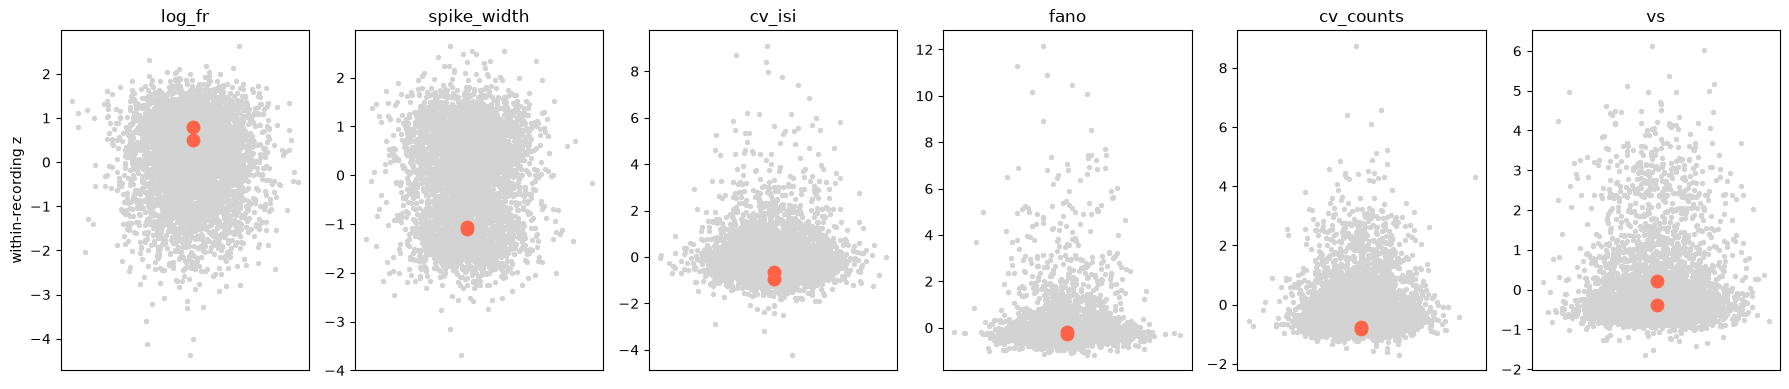

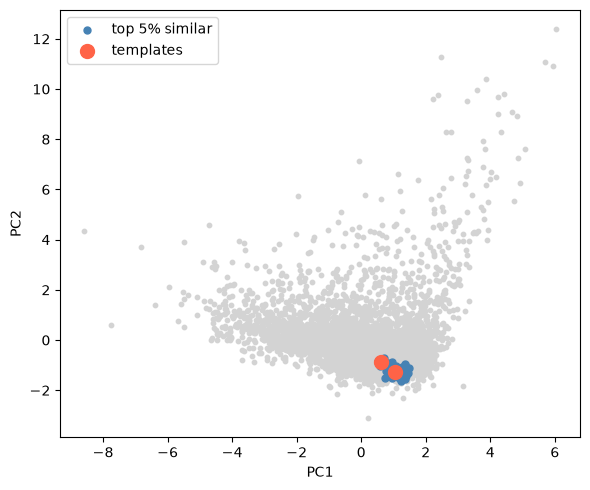

Top 5%: 45


In [6]:
# ---------------------------------------------------------
# Plot template feature values
# ---------------------------------------------------------
fig, axes = plt.subplots(
    1, len(feats),
    figsize=(3 * len(feats), 4)
)

for ax, f in zip(axes, feats):
    ax.scatter(
        np.random.normal(0, 0.05, len(z)),
        z[f],
        s=8,
        c='lightgray'
    )

    ax.scatter(
        np.zeros(len(template_idx)),
        z.loc[template_idx, f],
        s=80,
        c='tomato',
        zorder=3
    )

    ax.set_title(f)
    ax.set_xticks([])

axes[0].set_ylabel('within-recording z')
plt.tight_layout()


# ---------------------------------------------------------
# PCA
# ---------------------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pcs = pca.fit_transform(z.values)

# Add PCA coordinates to df_valid so indexing stays aligned
df_valid['PC1'] = pcs[:, 0]
df_valid['PC2'] = pcs[:, 1]

# Top 20% most similar neurons
n_top = int(0.01 * len(df_valid))
top = df_valid.nsmallest(n_top, 'dist')

# ---------------------------------------------------------
# PCA plot
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))

plt.scatter(
    df_valid['PC1'],
    df_valid['PC2'],
    c='lightgray',
    s=10
)

plt.scatter(
    top['PC1'],
    top['PC2'],
    c='steelblue',
    s=25,
    label='top 5% similar'
)

plt.scatter(
    df_valid.loc[template_idx, 'PC1'],
    df_valid.loc[template_idx, 'PC2'],
    c='tomato',
    s=100,
    label='templates',
    zorder=3
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Top 5%: {n_top}')

In [7]:
closest = df_valid.nsmallest(n_top, 'dist')

closest_list = list(
    zip(
        closest['recording'],
        closest['neuron']
    )
)

for _, row in closest.iterrows():
    print(f"{row['recording']} | neuron {row['neuron']} | dist = {row['dist']:.3f}")

# Export to Excel
output = closest[['recording', 'neuron']].copy()
output = output.rename(columns={'neuron': 'unit'})
output['SI'] = ''

output.to_excel('closest_neurons.xlsx', index=False)

# Remaining 80% of neurons
remaining = df_valid.drop(top.index)

# Save remaining neurons
remaining_output = remaining[['recording', 'neuron']].copy()
remaining_output = remaining_output.rename(columns={'neuron': 'unit'})
remaining_output['SI'] = ''
remaining_output.to_excel('furthest_neurons.xlsx', index=False)

w46o62 Recording #2 (77-H2, Field L, 1.4AP 1.2ML-R 2231um) | neuron 226 | dist = 0.000
o3o55 Recording #2 (77-H2, Field L, 1.4AP 1.2ML-R 1708um) | neuron 217 | dist = 0.000
o27g88 Recording #3 (H7, Field L, 1.25AP 1.2ML-L 1999um) | neuron 114 | dist = 0.241
o1o2 Recording #8 (77-H2, 1.4AP 1.2ML-L 2194um) | neuron 14 | dist = 0.294
w65g13 Recording #3 (E1-, HVC, 0AP 2.4ML-L, 503um) | neuron 9 | dist = 0.326
w46o62 Recording #2 (77-H2, Field L, 1.4AP 1.2ML-R 2231um) | neuron 248 | dist = 0.336
o27g88 Recording #4 (H7, Field L, 1.25AP 1.2ML-L 2705um) | neuron 151 | dist = 0.360
w70k80 Recording #2 (H7, Field L, 1.4AP 1.2ML-R 2604um) | neuron 97 | dist = 0.363
w70k80 Recording #4 (H7, Field L, 1.25AP 1.2ML-L 2561um) | neuron 110 | dist = 0.403
o3o55 Recording #1 (77-H2, Field L, 1.4AP 1.2ML-R 1005um) | neuron 163 | dist = 0.408
o3o4 Recording #4 (E1-, HVC, 0AP 2.4ML-L 616um) | neuron 87 | dist = 0.409
w4g19 Recording #3 (77-H2, Field L, 1.~ AP 1.2ML-R 2803um) | neuron 38 | dist = 0.415
w70